In [1]:
import datetime
import numpy as np
import pickle
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from dateutil import parser

In [2]:
S_taxi_miles = "taxi_miles"
S_taxi_only_trips = "taxi_only_trips"
S_one_bus_trips = "one_bus_trips"
S_two_bus_trips = "two_bus_trips"
S_unserved_trips = "unserved_trips"
S_starts_at = "starts_at"

DROPOFF_LAT = 'dropoff_latitude'
DROPOFF_LONG = 'dropoff_longitude'
PICKUP_LAT = 'pickup_latitude'
PICKUP_LONG = 'pickup_longitude'
PICKUP_TIME = 'tpep_pickup_datetime'
TRIP_DISTANCE = 'trip_distance'
ORIGIN = 'origin'
DEST = 'dest'


In [15]:
dateparse = lambda dates: [datetime.datetime.strptime(d, '%Y-%m-%d %H:%M:%S') for d in dates]
    
selected = pd.read_csv("manhatton/input.csv", parse_dates=[PICKUP_TIME], date_parser=dateparse).sort_values(by = [PICKUP_TIME])

# selected = pd.read_csv("manhatton/input.csv",parse_dates=True).sort_values(by = [PICKUP_TIME])

In [16]:
start_time = parser.parse("2015-01-01 00:00:00")
end_time = parser.parse("2015-01-02 00:00:00")
x = []
y = []
window_end = start_time + datetime.timedelta(minutes=1)
while window_end <= end_time:
    selected_window = selected.loc[(selected[PICKUP_TIME] >= start_time) & 
                                (selected[PICKUP_TIME] < window_end)]
    x.append(start_time)
    y.append(selected_window.shape[0])
    start_time = window_end
    window_end = start_time + datetime.timedelta(minutes=1)

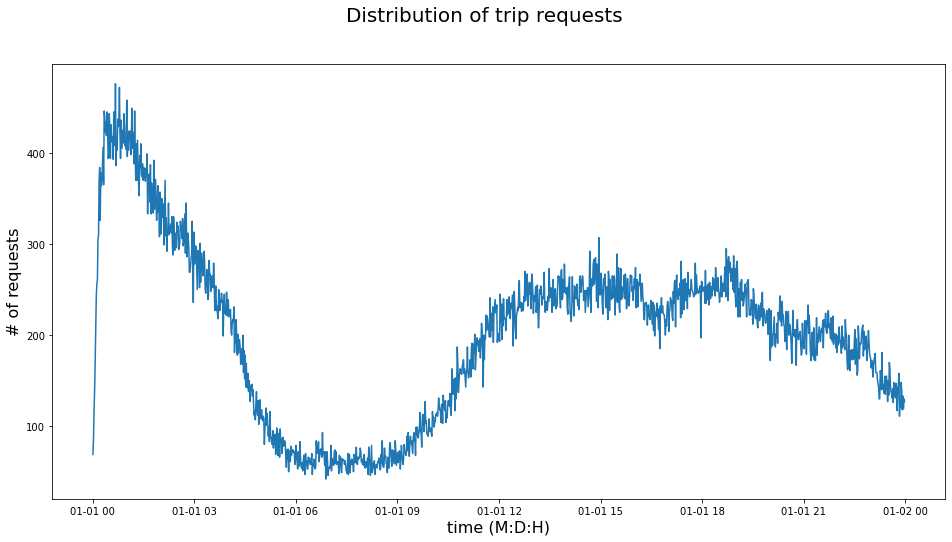

In [25]:
fig = plt.figure(figsize=(16,8))
plt.plot(x,y)
fig.suptitle('Distribution of trip requests', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('# of requests', fontsize=16)
# plt.show()
fig.savefig('graphs/trip_distribution.jpg')

In [4]:
dateparse_result = lambda dates: [datetime.datetime.strptime(d, '%Y.%m.%d %H:%M:%S') for d in dates]
taxi_only_results = pd.read_csv("process_results/stats.csv", parse_dates=[S_starts_at], date_parser=dateparse_result).sort_values(by = [S_starts_at])
with_bus_results = pd.read_csv("process_results/withbus/stats.csv", parse_dates=[S_starts_at], date_parser=dateparse_result).sort_values(by = [S_starts_at])

In [5]:
np.loadtxt("process_results/times.txt").mean(),np.loadtxt("process_results/times.txt").std()

(15.261470899683713, 3.9309301077132077)

In [6]:
np.loadtxt("process_results/withbus/times.txt").mean(),np.loadtxt("process_results/withbus/times.txt").std()

(46.248206036314166, 9.78723027455627)

In [7]:
taxi_only_results[S_taxi_miles].sum(),taxi_only_results[S_unserved_trips].sum()

(821982210.7682514, 1642)

In [18]:
(taxi_only_results[S_unserved_trips].sum()-with_bus_results[S_unserved_trips].sum())/taxi_only_results[S_unserved_trips].sum()

0.5609013398294762

In [13]:
# with_bus_results[S_taxi_miles].sum(),with_bus_results[S_unserved_trips].sum()
(taxi_only_results[S_taxi_miles].sum()-with_bus_results[S_taxi_miles].sum())/taxi_only_results[S_taxi_miles].sum()

0.3490710448412374

In [28]:
x_ta = taxi_only_results[S_taxi_only_trips].to_numpy()
x_1b = taxi_only_results[S_one_bus_trips].to_numpy()
x_2b = taxi_only_results[S_two_bus_trips].to_numpy()
x_un = taxi_only_results[S_unserved_trips].to_numpy()
x_tm = taxi_only_results[S_taxi_miles].to_numpy()
y = taxi_only_results[S_starts_at].to_numpy()


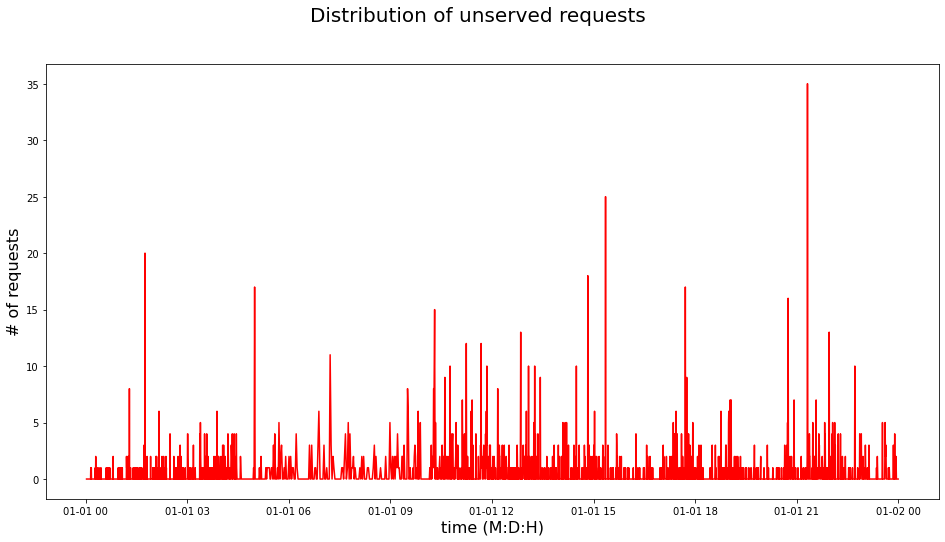

In [49]:
fig = plt.figure(figsize=(16,8))

# plt.plot(x_ta, mus, 'r', label="μ")
# plt.plot(x_1b, r_ps, 'b', label="r_p")
# plt.plot(x_2b, r_ds, 'g', label="r_d")
plt.plot(y, x_un, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of unserved requests', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('# of requests', fontsize=16)
plt.show()
# fig.savefig('graphs/unserved_trip_distribution_without_bus.jpg')

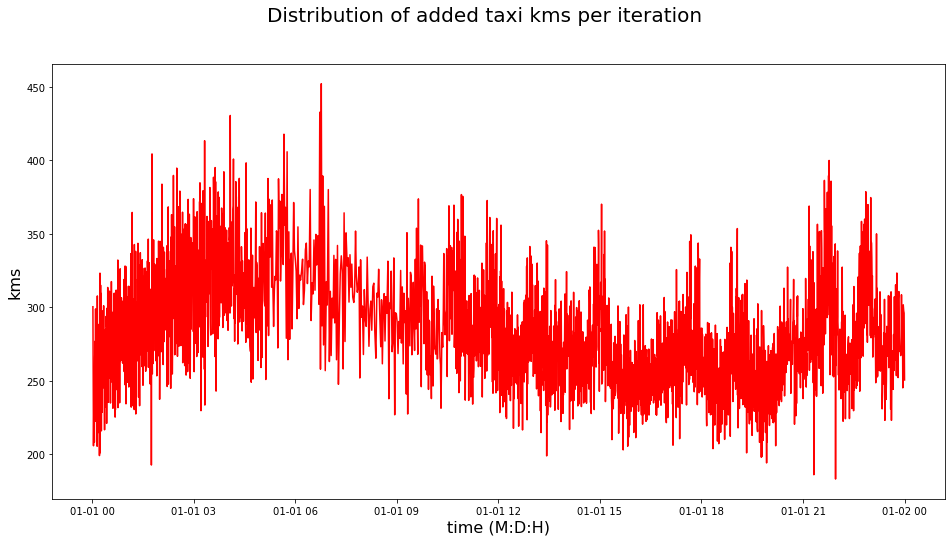

In [51]:
fig = plt.figure(figsize=(16,8))

# plt.plot(x_ta, mus, 'r', label="μ")
# plt.plot(x_1b, r_ps, 'b', label="r_p")
# plt.plot(x_2b, r_ds, 'g', label="r_d")
plt.plot(y, x_tm/1000, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of added taxi kms per iteration', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('kms', fontsize=16)
# plt.show()
fig.savefig('graphs/taxi_miles_distribution_without_bus.jpg')

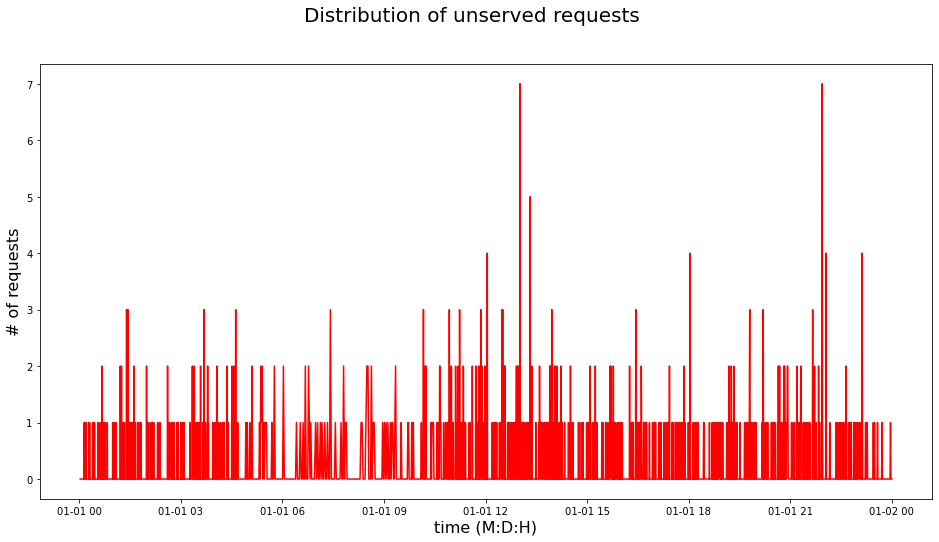

In [20]:
y_ta = with_bus_results[S_taxi_only_trips].to_numpy()
y_1b = with_bus_results[S_one_bus_trips].to_numpy()
y_2b = with_bus_results[S_two_bus_trips].to_numpy()
y_un = with_bus_results[S_unserved_trips].to_numpy()
y_tm = with_bus_results[S_taxi_miles].to_numpy()
x = with_bus_results[S_starts_at].to_numpy()


fig = plt.figure(figsize=(16,8))

# plt.plot(x_ta, mus, 'r', label="μ")
# plt.plot(x_1b, r_ps, 'b', label="r_p")
# plt.plot(x_2b, r_ds, 'g', label="r_d")
plt.plot(x, y_un, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of unserved requests', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('# of requests', fontsize=16)
# plt.show()
fig.savefig('graphs/unserved_trip_distribution_with_bus.jpg')

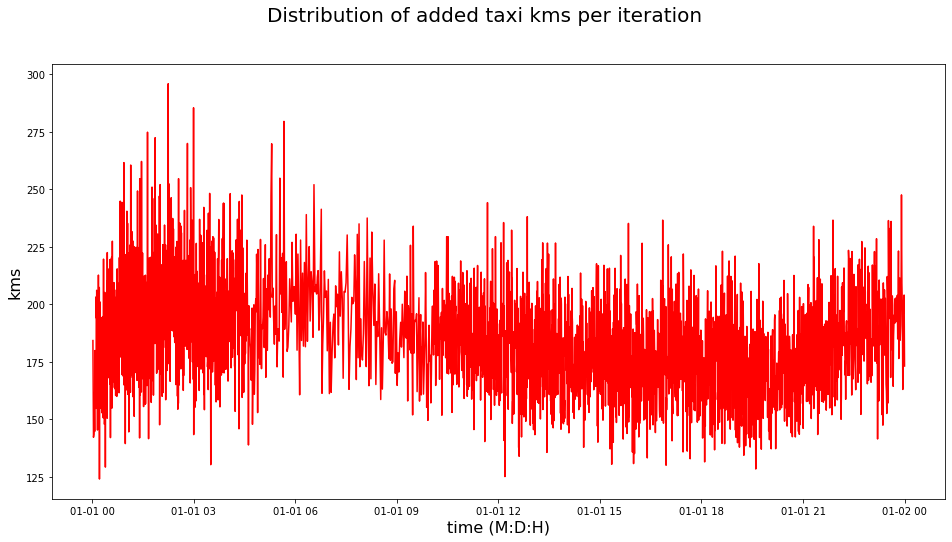

In [21]:
fig = plt.figure(figsize=(16,8))

# plt.plot(x_ta, mus, 'r', label="μ")
# plt.plot(x_1b, r_ps, 'b', label="r_p")
# plt.plot(x_2b, r_ds, 'g', label="r_d")
plt.plot(x, y_tm/1000, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of added taxi kms per iteration', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('kms', fontsize=16)
# plt.show()
fig.savefig('graphs/taxi_miles_distribution_with_bus.jpg')

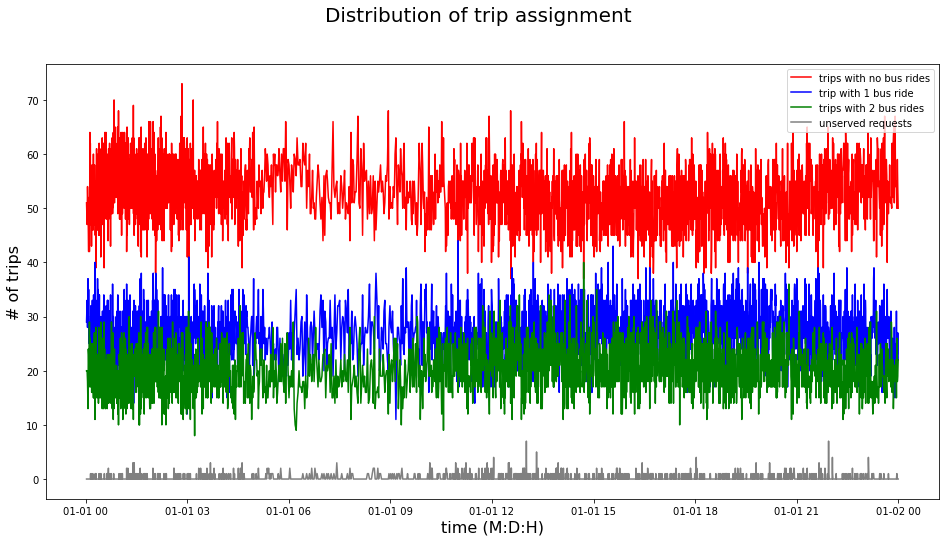

In [26]:
fig = plt.figure(figsize=(16,8))

plt.plot(x, y_ta, 'r', label="trips with no bus rides")
plt.plot(x, y_1b, 'b', label="trip with 1 bus ride")
plt.plot(x, y_2b, 'g', label="trips with 2 bus rides")
plt.plot(x, y_un, 'gray', label="unserved requests")
# plt.plot(x, y_tm/1000, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of trip assignment', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('# of trips', fontsize=16)
plt.legend()
# plt.show()
fig.savefig('graphs/assignment_typedistribution_with_bus.jpg')

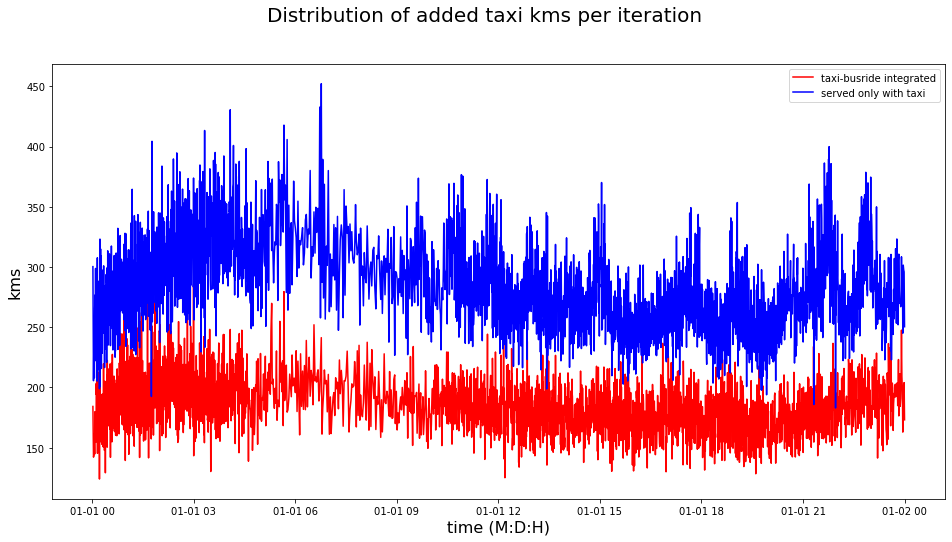

In [30]:
fig = plt.figure(figsize=(16,8))

plt.plot(x, y_tm/1000, 'r', label="taxi-busride integrated")
plt.plot(x, x_tm/1000, 'b', label="served only with taxi")
# plt.plot(x, y_tm/1000, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of added taxi kms per iteration', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('kms', fontsize=16)
plt.legend()
# plt.show()
fig.savefig('graphs/compare_distribution_taxi_mile.jpg')

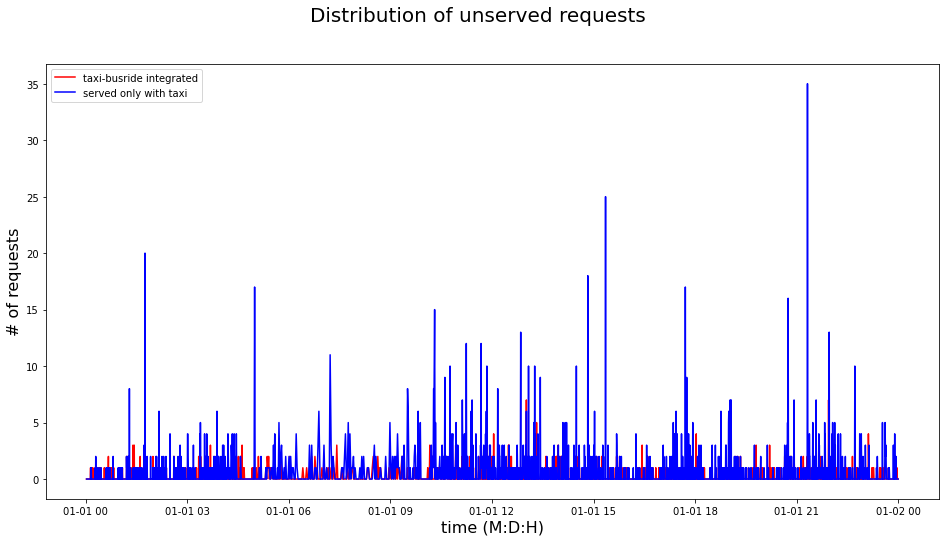

In [33]:
fig = plt.figure(figsize=(16,8))

plt.plot(x, y_un, 'r', label="taxi-busride integrated")
plt.plot(x, x_un, 'b', label="served only with taxi")
# plt.plot(x, y_tm/1000, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Distribution of unserved requests', fontsize=20)
plt.xlabel('time (M:D:H)', fontsize=16)
plt.ylabel('# of requests', fontsize=16)
plt.legend()
# plt.show()
fig.savefig('graphs/compare_distribution_unserved_trips.jpg')

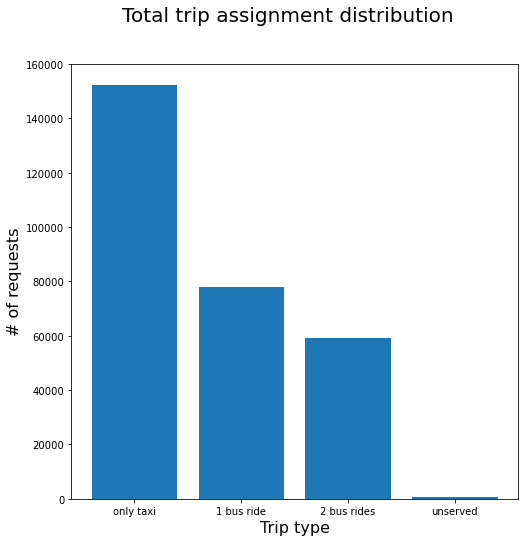

In [38]:
fig = plt.figure(figsize=(8,8))

x_types = ["only taxi","1 bus ride","2 bus rides","unserved"]
y_types = [with_bus_results[S_taxi_only_trips].sum(),
          with_bus_results[S_one_bus_trips].sum(),
          with_bus_results[S_two_bus_trips].sum(),
          with_bus_results[S_unserved_trips].sum()]
plt.bar(x_types, y_types)
# plt.bar(x, x_un, 'b', label="served only with taxi")
# plt.plot(x, y_tm/1000, 'r')
# plt.plot(x_tm, r_ds, 'g', label="r_d")

# plt.plot(x,y)
fig.suptitle('Total trip assignment distribution', fontsize=20)
plt.xlabel('Trip type', fontsize=16)
plt.ylabel('# of requests', fontsize=16)
# plt.legend()
# plt.show()
fig.savefig('graphs/trip_assignment_distribution.jpg')

In [44]:
(y_types[0])/sum(y_types)

0.5249178702039299